##### Universidad Autónoma de Guadalajara
Aprendizaje Automatizado para la Gestión de Datos Masivos   

Profesor: Paulo López Meyer. 

Estudiante: Anayansi Cristina Hernández Abrego. 

Código vistos en clase ( tarea 10). 

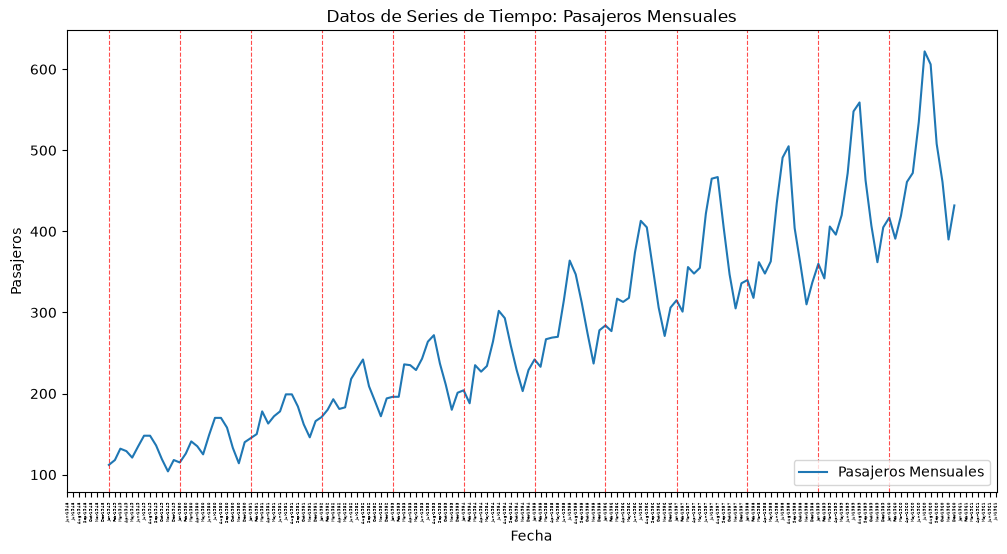

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# Cargar datos de ejemplo
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])
data = data.asfreq('MS')
series = data['Passengers']

# ----------------------------------------
# Plotear los datos
fig, ax = plt.subplots(figsize=(12, 6)) 
ax.plot(series, label='Pasajeros Mensuales')

# --- CONFIGURACIÓN DEL EJE X POR MES ---
# Colocar una marca en cada mes
ax.xaxis.set_major_locator(mdates.MonthLocator())  

# Formato de la etiqueta: %b muestra el nombre corto (ej. Jan, Feb o Ene, Feb) y %Y el año
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))  

# Rotar 90 grados para que las etiquetas queden verticales y no se encimen
plt.xticks(rotation=90, fontsize=3) 
anos_unicos = series.index.year.unique()
for ano in anos_unicos:
    fecha_ano_nuevo = pd.Timestamp(f'{ano}-01-01')
    ax.axvline(x=fecha_ano_nuevo, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
# ------------------------------------------------------------

# Plotear los datos

plt.title('Datos de Series de Tiempo: Pasajeros Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.show()

In [65]:
#Análisis exploratorio
data.shape
data.columns
print(data)
print(data.describe())
print(data.info)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000
<bound method DataFrame.info of             Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
...                ...
1960-08-01         606
1960-09-01         508
1960-10-01         461
1960-11-01         390
1960-12-01         432

[144 rows x 1 columns]>


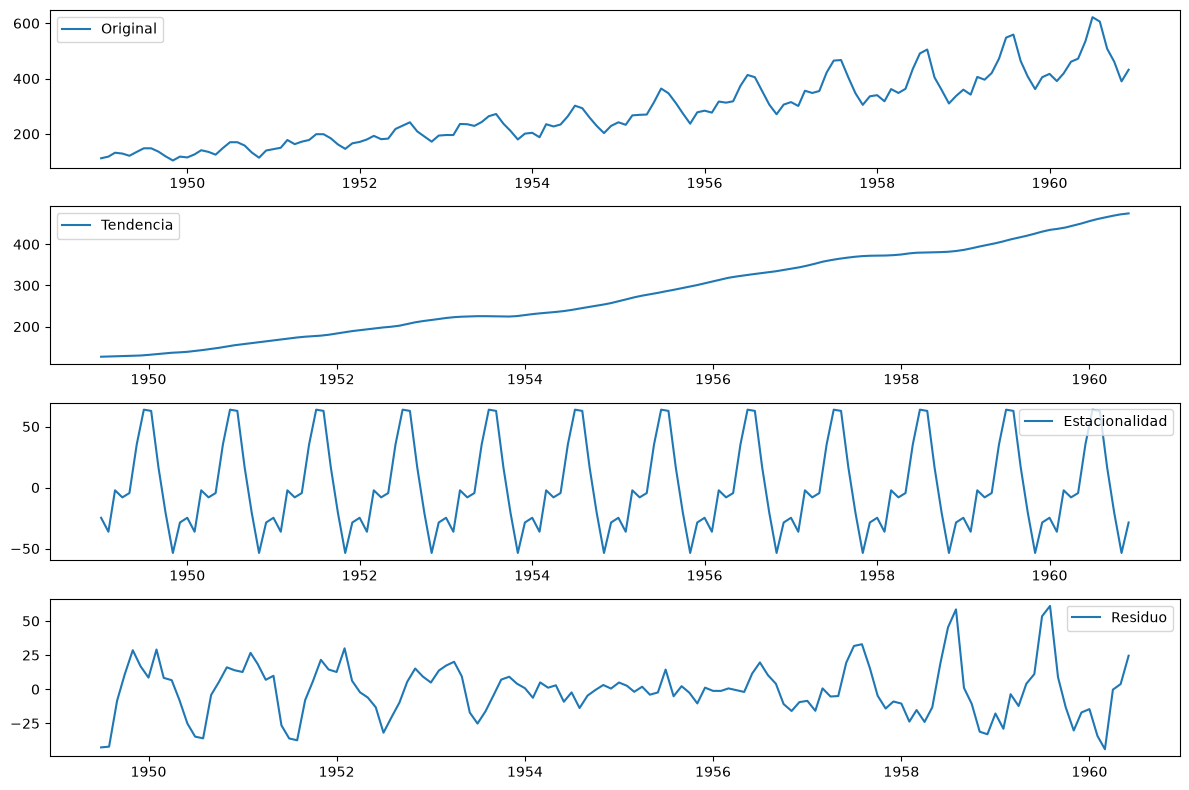

In [68]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomponer la serie de tiempo
decomposition = seasonal_decompose(series, model='additive')
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plotear los componentes
plt.figure(figsize=(12, 8))
plt.subplot(411)
plt.plot(series, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend, label='Tendencia')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(seasonal, label='Estacionalidad')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(residual, label='Residuo')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

--- RESULTADO DE LA SERIE ORIGINAL ---
Estadístico ADF: 0.8154
p-valor: 0.9919

--- RESULTADO TRAS LOGARITMO + DIFERENCIACIÓN REGULAR Y ESTACIONAL ---
Estadístico ADF: -4.4433
p-valor: 0.0002
Valores Críticos (1%): -3.4870
Valores Críticos (5%): -2.8864


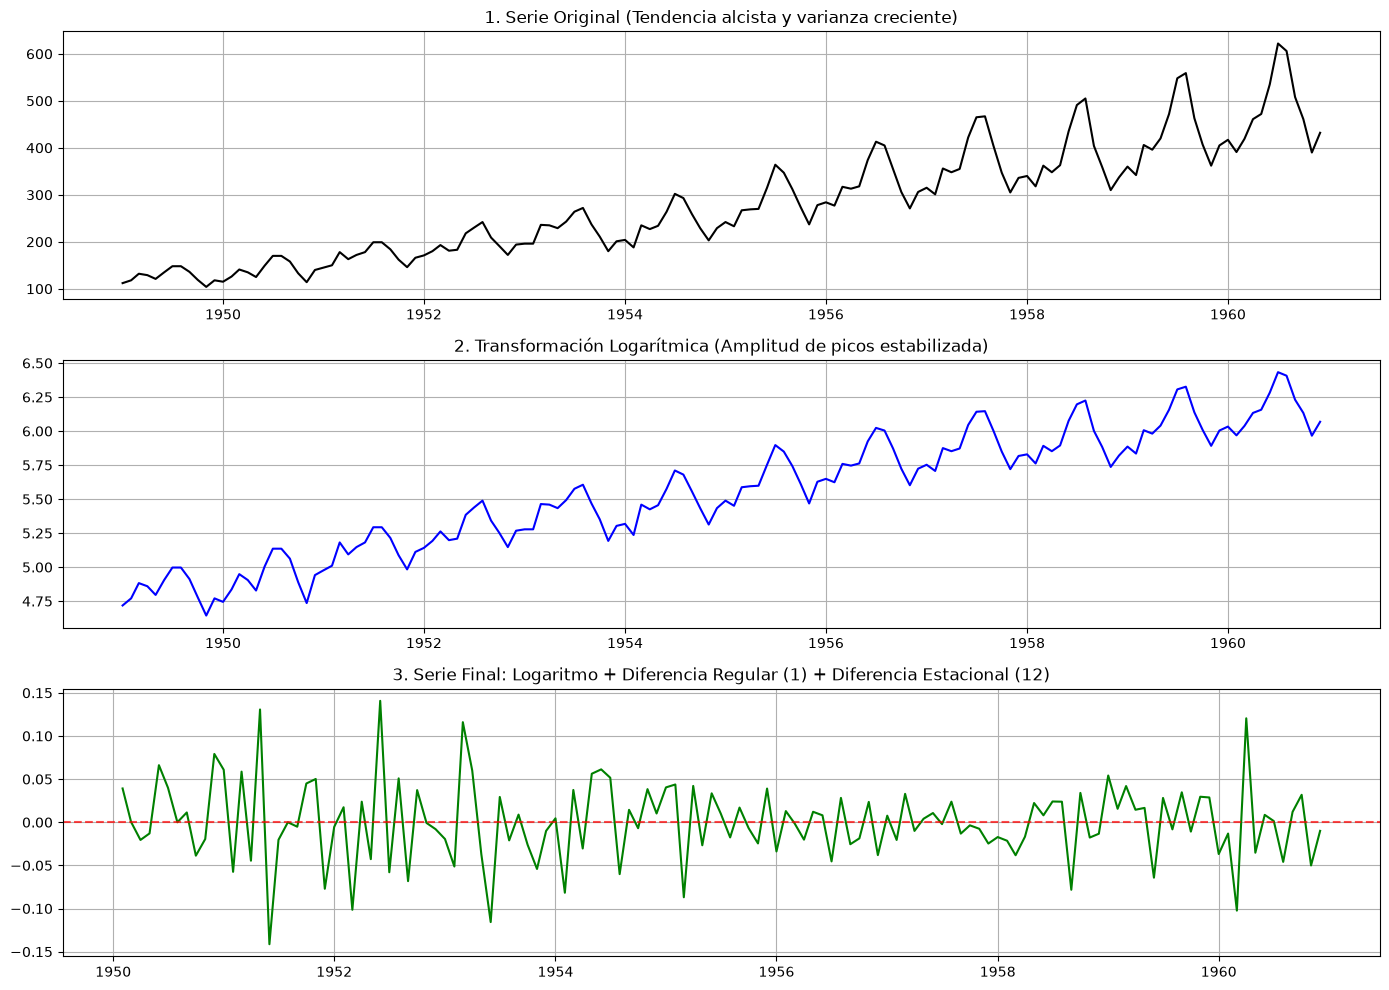

In [ ]:
## TRANSFORMACIÓN MATEMÁTICA PARA CORREGIR LA PRUEBA adfuller

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Carga limpia de los datos originales
df = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])
df = df.asfreq('MS')
series_original = df['Passengers']

# TRANFORMACIONES MATEMÁTICAS

# Paso A: Transformación Logarítmica (Estabiliza la VARIANZA / Heterocedasticidad)
series_log = np.log(series_original)

# Paso B: Diferenciación Regular (Elimina la TENDENCIA)
# Resta el mes actual con el mes anterior: Y_t - Y_(t-1)
series_diff_regular = series_log.diff().dropna()

# Paso C: Diferenciación Estacional (Elimina la ESTACIONALIDAD)
# Resta el valor actual con el del mismo mes del año pasado: Y_t - Y_(t-12)
series_estacionaria = series_diff_regular.diff(periods=12).dropna()

# PRUEBAS ESTADÍSTICAS (ADFULLER)

print("--- RESULTADO DE LA SERIE ORIGINAL ---")
res_orig = adfuller(series_original)
print(f"Estadístico ADF: {res_orig[0]:.4f}")
print(f"p-valor: {res_orig[1]:.4f}")

print("\n--- RESULTADO TRAS LOGARITMO + DIFERENCIACIÓN REGULAR Y ESTACIONAL ---")
res_trans = adfuller(series_estacionaria)
print(f"Estadístico ADF: {res_trans[0]:.4f}")
print(f"p-valor: {res_trans[1]:.4f}")
print(f"Valores Críticos (1%): {res_trans[4]['1%']:.4f}")
print(f"Valores Críticos (5%): {res_trans[4]['5%']:.4f}")

# VISUALIZACIÓN 

plt.figure(figsize=(14, 10))

# Gráfica 1: Serie Original (No estacionaria, varianza inestable)
plt.subplot(3, 1, 1)
plt.plot(series_original, color='black')
plt.title('1. Serie Original (Tendencia alcista y varianza creciente)')
plt.grid(True)

# Gráfica 2: Serie en Logaritmos (Varianza corregida, tendencia persiste)
plt.subplot(3, 1, 2)
plt.plot(series_log, color='blue')
plt.title('2. Transformación Logarítmica (Amplitud de picos estabilizada)')
plt.grid(True)

# Gráfica 3: Serie Diferenciada Final (Estacionaria)
plt.subplot(3, 1, 3)
plt.plot(series_estacionaria, color='green')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.title('3. Serie Final: Logaritmo + Diferencia Regular (1) + Diferencia Estacional (12)')
plt.grid(True)

plt.tight_layout()
plt.show()


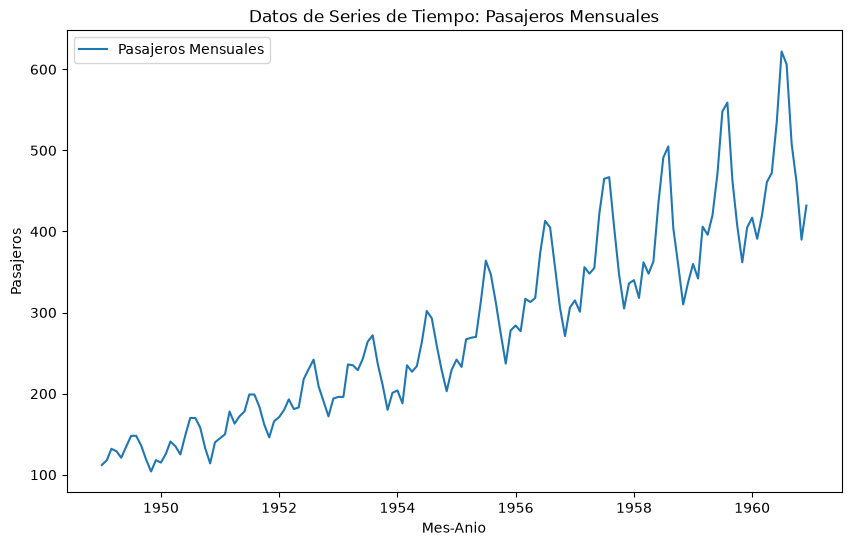

ADF Statistic: 0.8153688792060525
p-value: 0.991880243437641


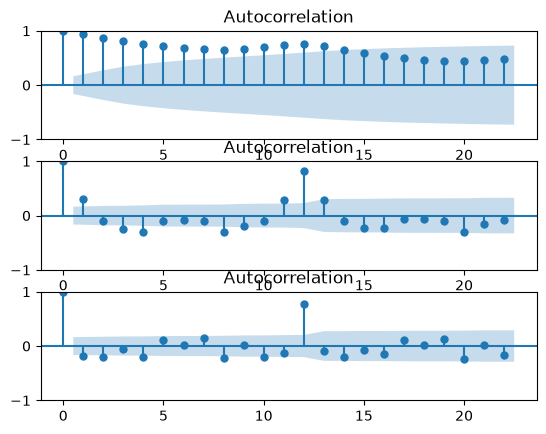

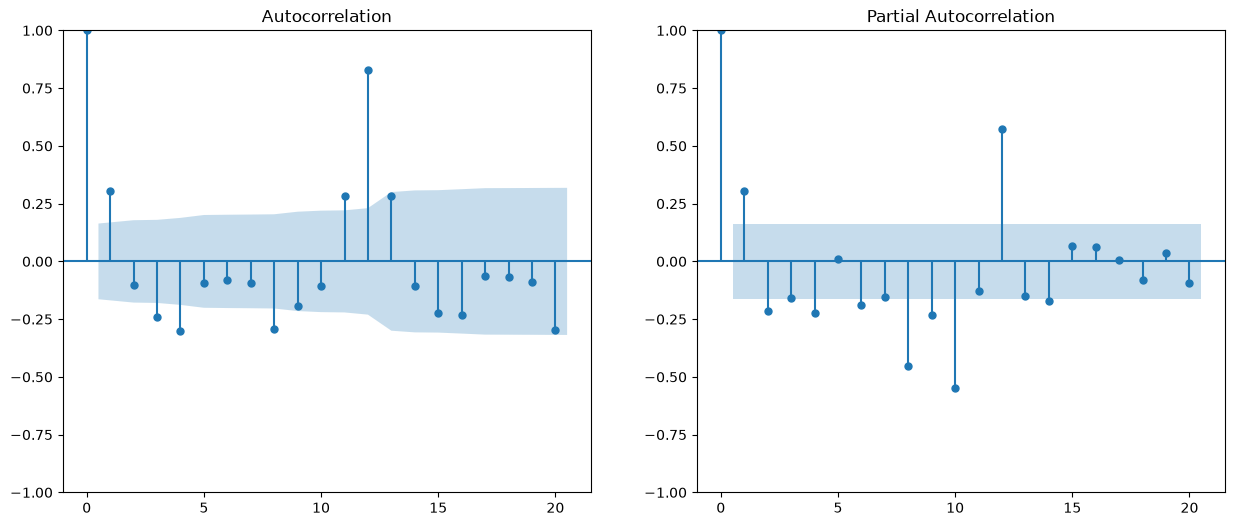

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Cargar datos 

# Plotear la serie de tiempo original
plt.figure(figsize=(10, 6))
plt.plot(series, label='Pasajeros Mensuales')
plt.title('Datos de Series de Tiempo: Pasajeros Mensuales')
plt.xlabel('Mes-Anio')
plt.ylabel('Pasajeros')
plt.legend()
plt.show()

# Verificar estacionariedad utilizando la prueba de Dickey-Fuller aumentada
result = adfuller(series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# Si la serie no es estacionaria, diferenciar los datos
differenced_series = series.diff().dropna()

from statsmodels.graphics.tsaplots import plot_acf 
fig, (ax1, ax2, ax3) = plt.subplots(3) 
plot_acf(series, ax=ax1) 
plot_acf(series.diff().dropna(), ax=ax2) 
plot_acf(series.diff().diff().dropna(), ax=ax3)

# Identificación de los parámetros p y q utilizando ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sm.graphics.tsa.plot_acf(differenced_series, lags=20, ax=axes[0])
sm.graphics.tsa.plot_pacf(differenced_series, lags=20, ax=axes[1])
plt.show()




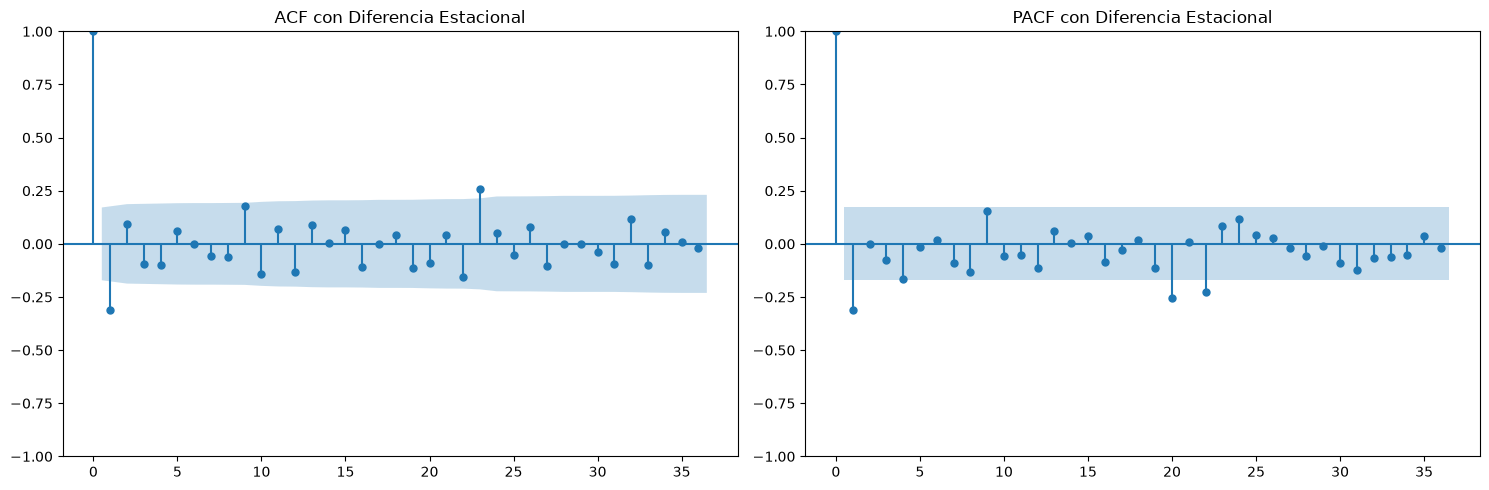

In [71]:
# Aplicar diferencia regular + diferencia estacional de 12 meses
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
estacional_series = series.diff().diff(12).dropna()

# Graficar el nuevo ACF y PACF para identificar los parámetros estacionales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(estacional_series, lags=36, ax=axes[0], title="ACF con Diferencia Estacional")
plot_pacf(estacional_series, lags=36, ax=axes[1], title="PACF con Diferencia Estacional")
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(3, 1, 3)   Log Likelihood                -665.969
Date:                Mon, 27 Jul 2026   AIC                           1345.938
Time:                        19:28:01   BIC                           1366.678
Sample:                    01-01-1949   HQIC                          1354.366
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0099      0.158      6.372      0.000       0.699       1.321
ar.L2          0.1660      0.255      0.651      0.515      -0.334       0.666
ar.L3         -0.6230      0.151     -4.119      0.0

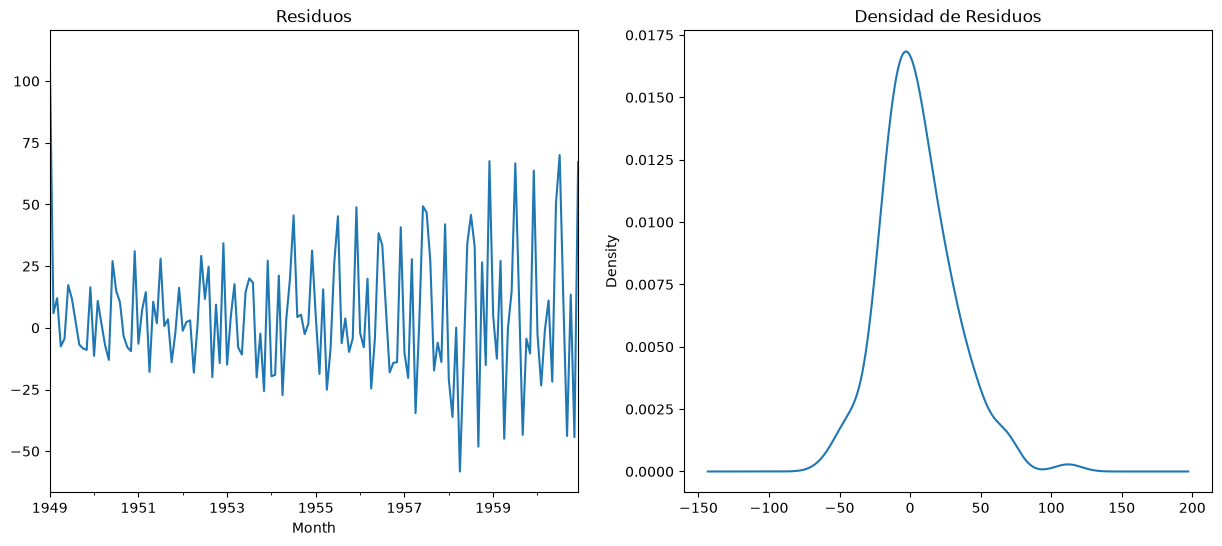

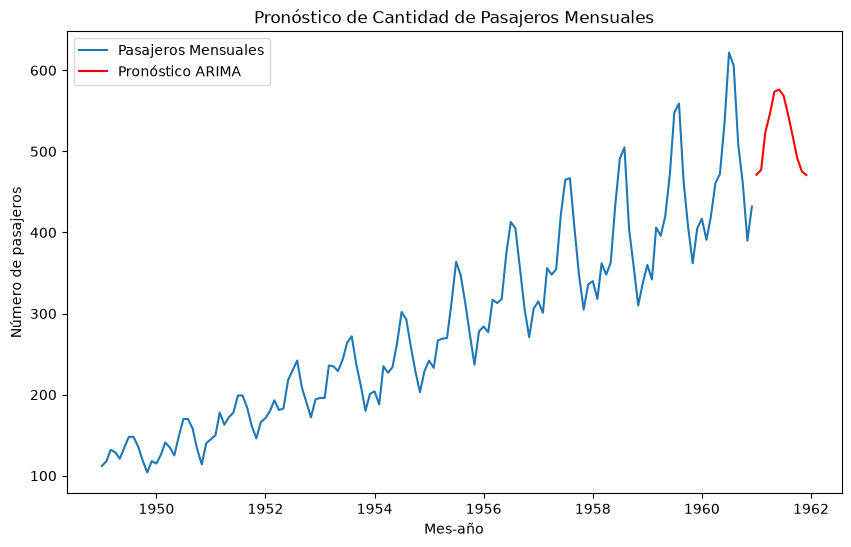

In [ ]:
# NO APLICA
# Construcción del modelo ARIMA
#model = ARIMA(series, order=(7, 1, 2))  # Ajustar p, d, q según los gráficos ACF y PACF
model = ARIMA(series, order=(3, 1, 3))
model_fit = model.fit()

# Resumen del modelo
print(model_fit.summary())

# Diagnóstico de residuos
residuals = model_fit.resid
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
residuals.plot(title="Residuos", ax=axes[0])
residuals.plot(kind='kde', title='Densidad de Residuos', ax=axes[1])
plt.show()

# Pronóstico
forecast = model_fit.forecast(steps=12)
plt.figure(figsize=(10, 6))
plt.plot(series, label='Pasajeros Mensuales')
plt.plot(forecast, label='Pronóstico ARIMA', color='red')
plt.title('Pronóstico de Cantidad de Pasajeros Mensuales')
plt.xlabel('Mes-año')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.show()

RESUMEN DEL MODELO SARIMA
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -457.315
Date:                            Tue, 28 Jul 2026   AIC                            920.631
Time:                                    22:46:56   BIC                            928.917
Sample:                                01-01-1949   HQIC                           923.995
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3175      0.073     -4.342      0.000      -0.461      -0.174
ma.S.L12 

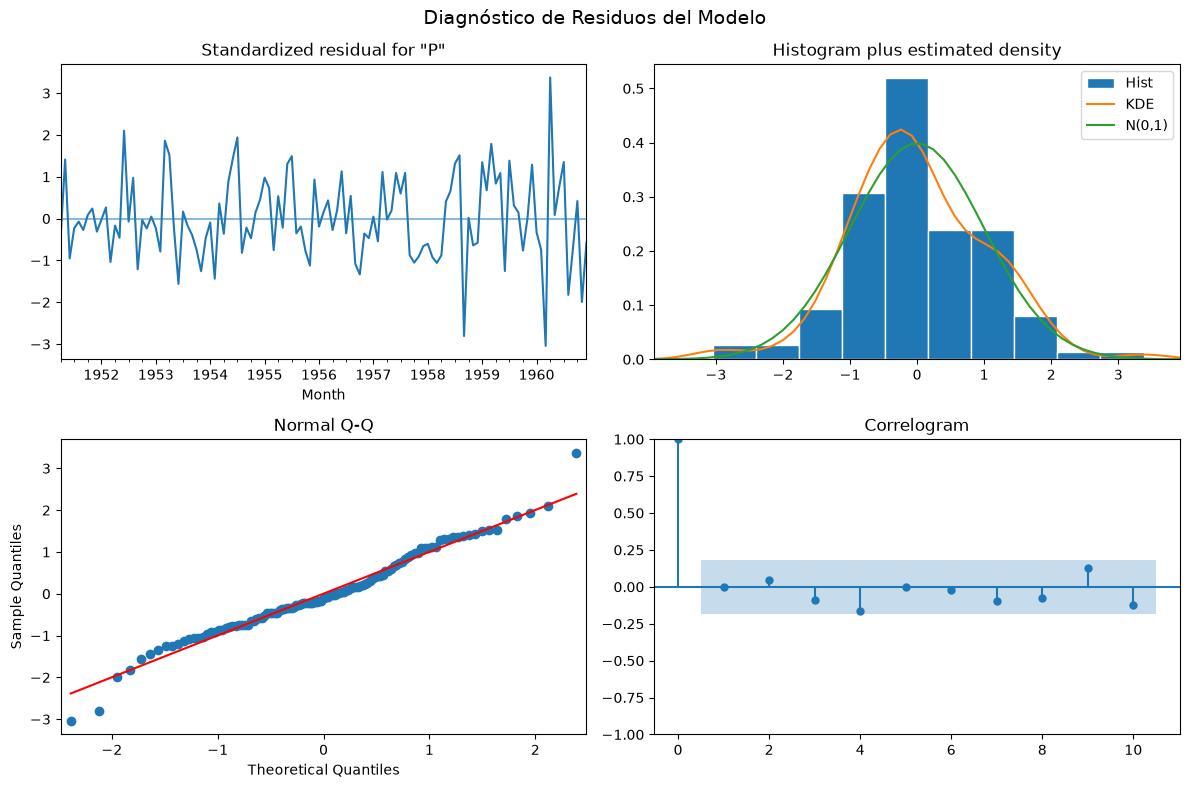

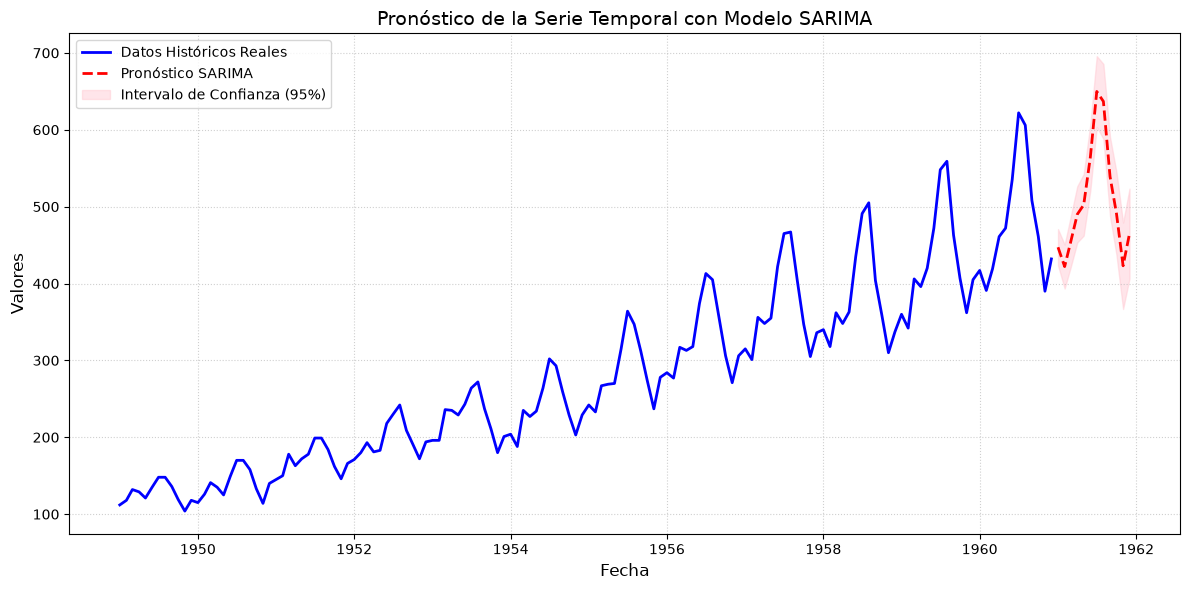

In [ ]:
# SARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# DATOS
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])
data = data.asfreq('MS')
series = data['Passengers']

# MODELO SARIMA
# ==========================================
# Parámetros basados en  gráficas ACF/PACF:
# order=(p, d, q) -> d=1 (diferencia regular), p=1 (AR1), q=1 (MA1)
# seasonal_order=(P, D, Q, s) -> D=1 (diferencia estacional), Q=1 (MA estacional), s=12 (ciclo anual)

modelo_sarima = sm.tsa.statespace.SARIMAX(
    series,
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado = modelo_sarima.fit(disp=False)

# EVALUACIÓN Y DIAGNÓSTICO

# Resumen estadístico (Métricas AIC, BIC y P-values de los coeficientes)
print("="*60)
print("RESUMEN DEL MODELO SARIMA")
print("="*60)
print(resultado.summary())

# Gráfica del diagnóstico de residuos
resultado.plot_diagnostics(figsize=(12, 8))
plt.suptitle("Diagnóstico de Residuos del Modelo", fontsize=14)
plt.tight_layout()
plt.show()

# PREDICCIÓN 
# meses hacia el futuro que se van a predecir
meses_a_predecir = 12

# Generar pronóstico e intervalos de confianza
pronostico = resultado.get_forecast(steps=meses_a_predecir)
pred_media = pronostico.predicted_mean
intervalo_confianza = pronostico.conf_int(alpha=0.05) # 95% de confianza

# VISUALIZACIÓN DE LOS RESULTADOS
plt.figure(figsize=(12, 6))

# Graficar datos históricos
plt.plot(series.index, series, label='Datos Históricos Reales', color='blue', lw=2)

# Graficar predicción futura
plt.plot(pred_media.index, pred_media, label='Pronóstico SARIMA', color='red', linestyle='--', lw=2)

# Graficar sombreado del intervalo de confianza
plt.fill_between(
    intervalo_confianza.index,
    intervalo_confianza.iloc[:, 0],
    intervalo_confianza.iloc[:, 1],
    color='pink',
    alpha=0.4,
    label='Intervalo de Confianza (95%)'
)

plt.title('Pronóstico de la Serie Temporal con Modelo SARIMA', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valores', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


RESUMEN DEL MODELO SARIMA - AIRPASSENGERS
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -398.706
Date:                            Tue, 28 Jul 2026   AIC                            803.411
Time:                                    22:46:14   BIC                            811.373
Sample:                                01-01-1949   HQIC                           806.637
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2244      0.090     -2.501      0.012      -0.400      

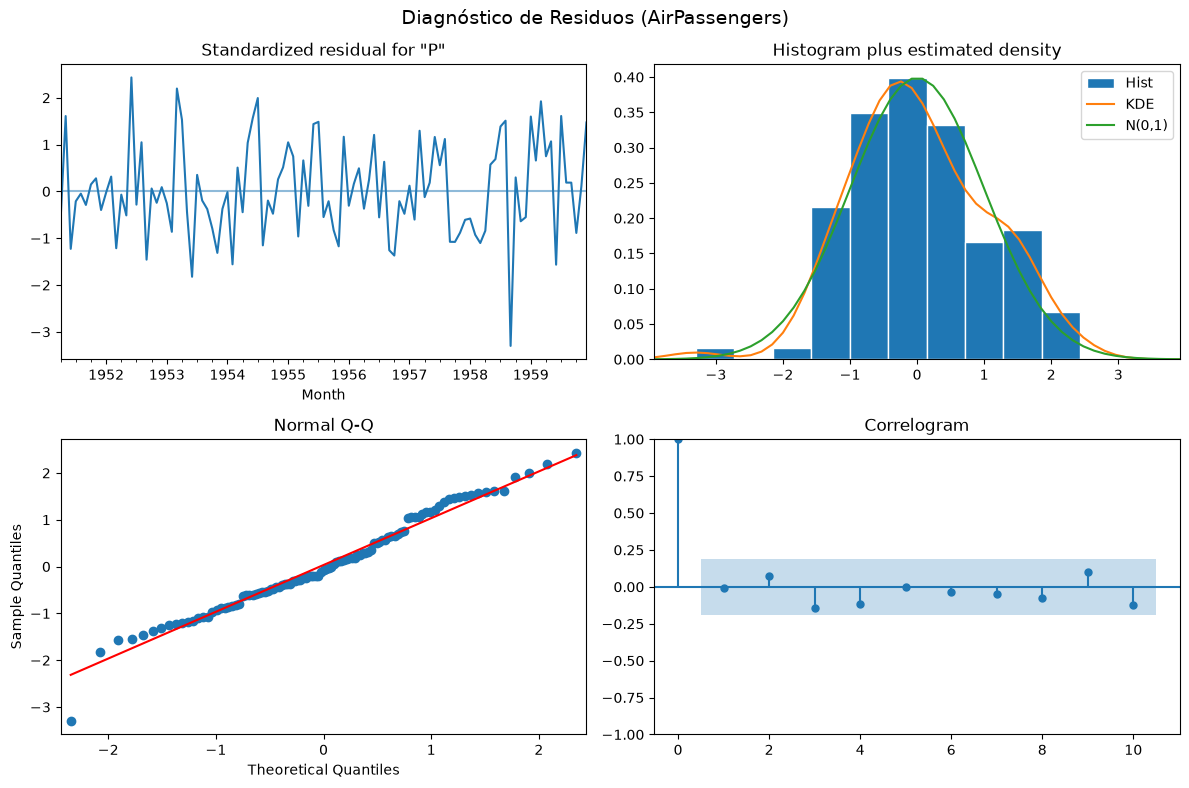

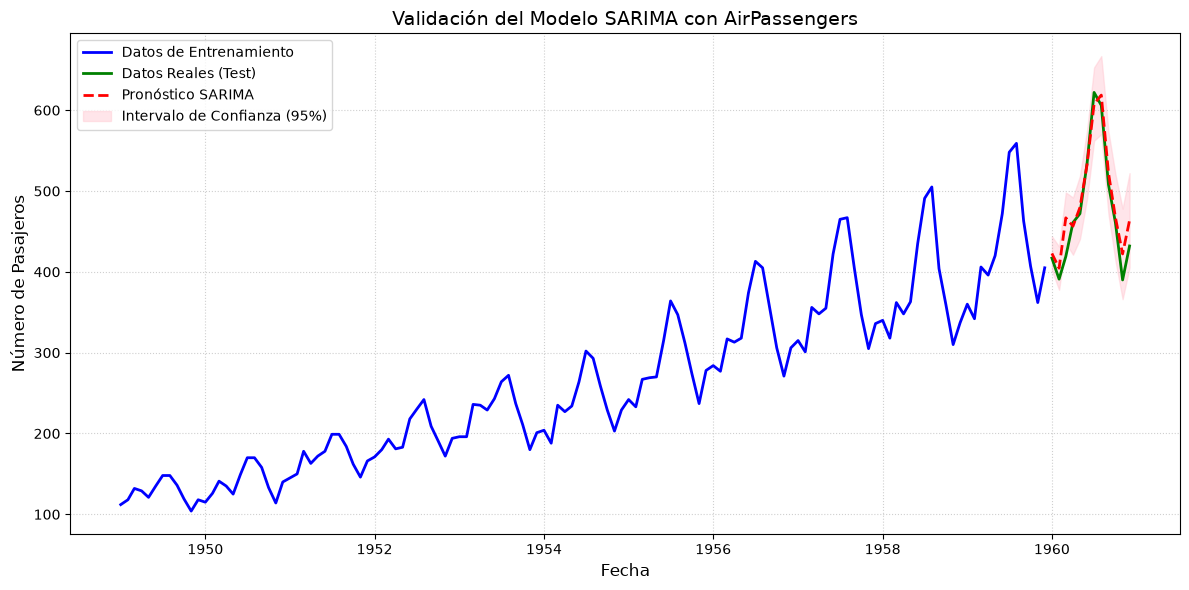

In [ ]:
# SARIMAX - SEPARANDO EL ÚLTIMO AÑO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# DATOS
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])
data = data.asfreq('MS')
series = data['Passengers']

# Dividimos los datos: dejamos los últimos 12 meses para evaluar la precisión
train_series = series.iloc[:-12]
test_series = series.iloc[-12:]

# CONFIGURACIÓN Y AJUSTE DEL MODELO
# Usamos el modelo SARIMA(1,1,1)x(0,1,1)12 que identificamos en las gráficas
modelo_sarima = sm.tsa.statespace.SARIMAX(
    train_series,                 # Entrenamos con los datos históricos
    order=(0, 1, 1),              # (p, d, q) regular
    seasonal_order=(0, 1, 1, 12), # (P, D, Q, s) estacional
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado = modelo_sarima.fit(disp=False)

# DIAGNÓSTICO 
print("="*60)
print("RESUMEN DEL MODELO SARIMA - AIRPASSENGERS")
print("="*60)
print(resultado.summary())

# Mostrar gráficos de diagnóstico de residuos
resultado.plot_diagnostics(figsize=(12, 8))
plt.suptitle("Diagnóstico de Residuos (AirPassengers)", fontsize=14)
plt.tight_layout()
plt.show()

# PRONÓSTICO SOBRE EL PERIODO DE PRUEBA
# Predecimos los 12 meses que guardamos para validar el modelo
pronostico = resultado.get_forecast(steps=12)
pred_media = pronostico.predicted_mean
intervalo_confianza = pronostico.conf_int(alpha=0.05) # 95% confianza

# VISUALIZACIÓN DE LA VALIDACIÓN
plt.figure(figsize=(12, 6))

# Datos de entrenamiento
plt.plot(train_series.index, train_series, label='Datos de Entrenamiento', color='blue', lw=2)

# Datos reales de prueba (lo que realmente pasó)
plt.plot(test_series.index, test_series, label='Datos Reales (Test)', color='green', lw=2)

# Pronóstico del modelo
plt.plot(pred_media.index, pred_media, label='Pronóstico SARIMA', color='red', linestyle='--', lw=2)

# Intervalo de confianza
plt.fill_between(
    intervalo_confianza.index,
    intervalo_confianza.iloc[:, 0],
    intervalo_confianza.iloc[:, 1],
    color='pink',
    alpha=0.4,
    label='Intervalo de Confianza (95%)'
)

plt.title('Validación del Modelo SARIMA con AirPassengers', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Número de Pasajeros', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


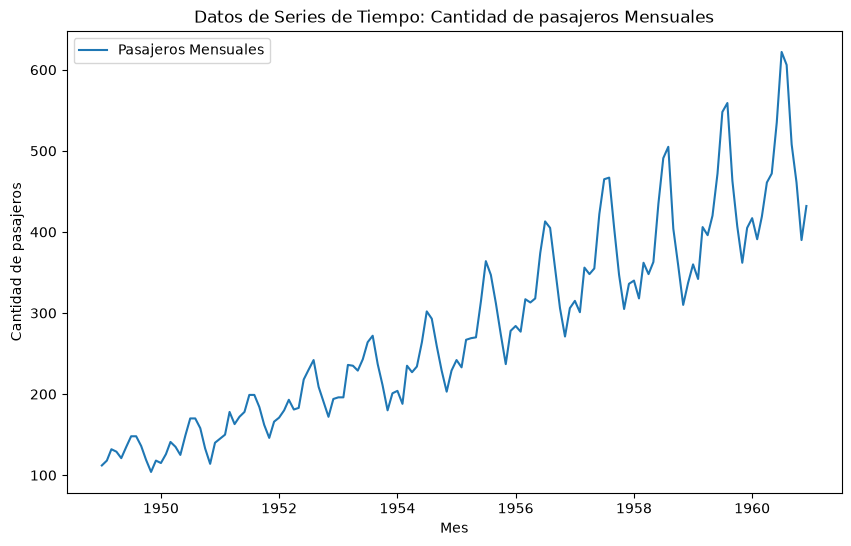

00:16:31 - cmdstanpy - INFO - Chain [1] start processing
00:16:31 - cmdstanpy - INFO - Chain [1] done processing


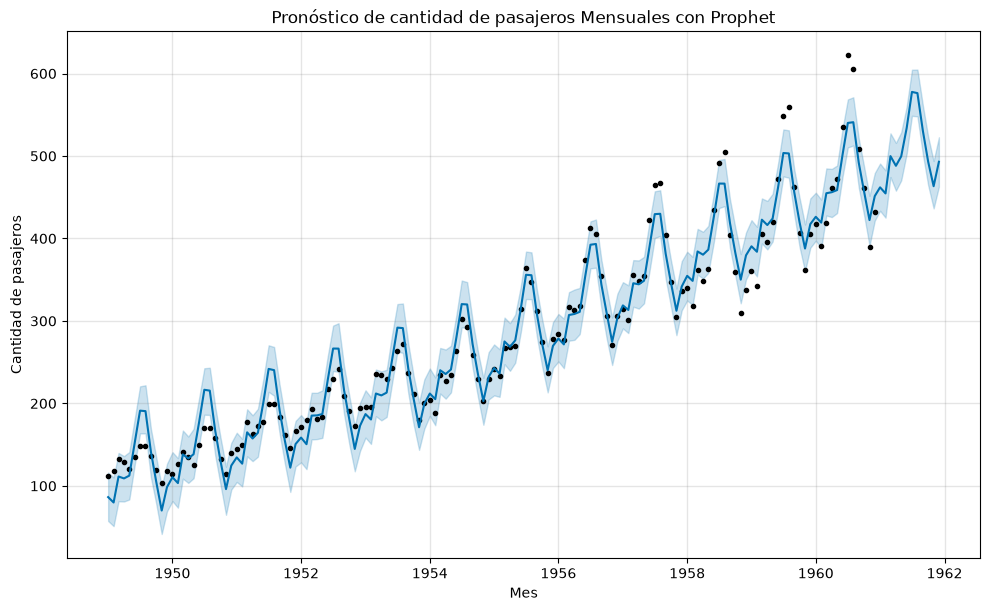

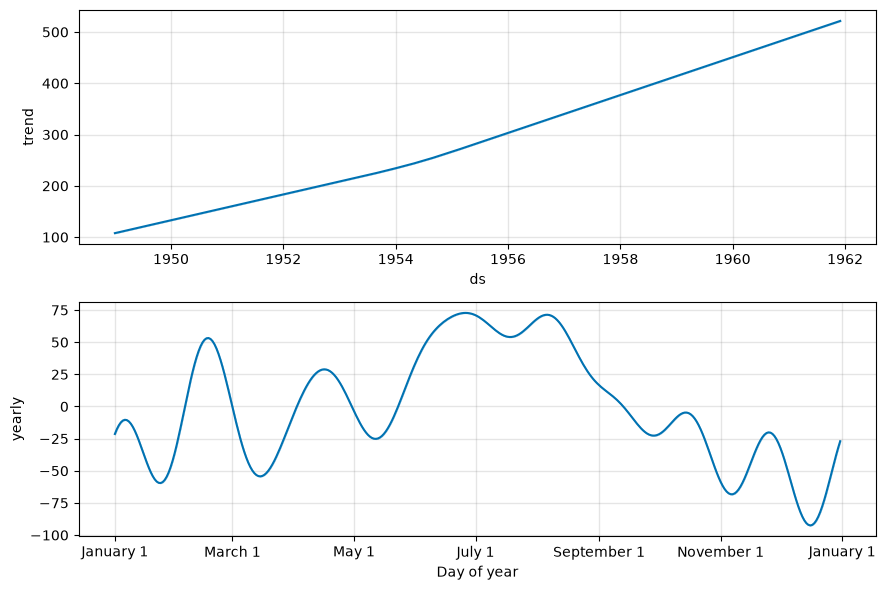

In [ ]:
# PROPHET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# Cargar datos 
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])
data = data.asfreq('MS')
series = data['Passengers']

data = data.reset_index()
data.columns = ['ds', 'y']

# Visualizar datos
plt.figure(figsize=(10, 6))
plt.plot(data['ds'], data['y'], label='Pasajeros Mensuales')
plt.title('Datos de Series de Tiempo: Cantidad de pasajeros Mensuales')
plt.xlabel('Mes')
plt.ylabel('Cantidad de pasajeros')
plt.legend()
plt.show()

# Construir el modelo Prophet
model = Prophet()
model.fit(data)

# Realizar pronósticos
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)

# Visualizar pronósticos
fig = model.plot(forecast)
plt.title('Pronóstico de cantidad de pasajeros Mensuales con Prophet')
plt.xlabel('Mes')
plt.ylabel('Cantidad de pasajeros')
plt.show()

# Visualizar componentes del modelo
fig2 = model.plot_components(forecast)
plt.show()


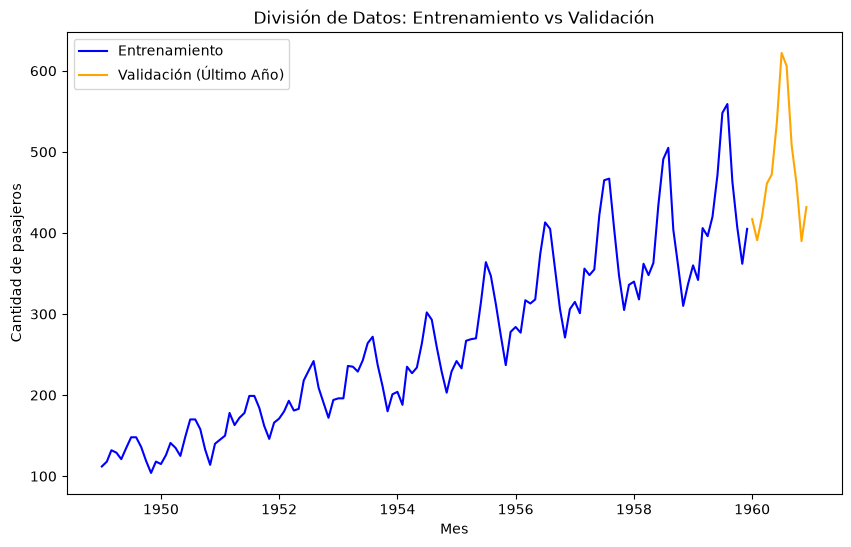

00:06:21 - cmdstanpy - INFO - Chain [1] start processing
00:06:21 - cmdstanpy - INFO - Chain [1] done processing


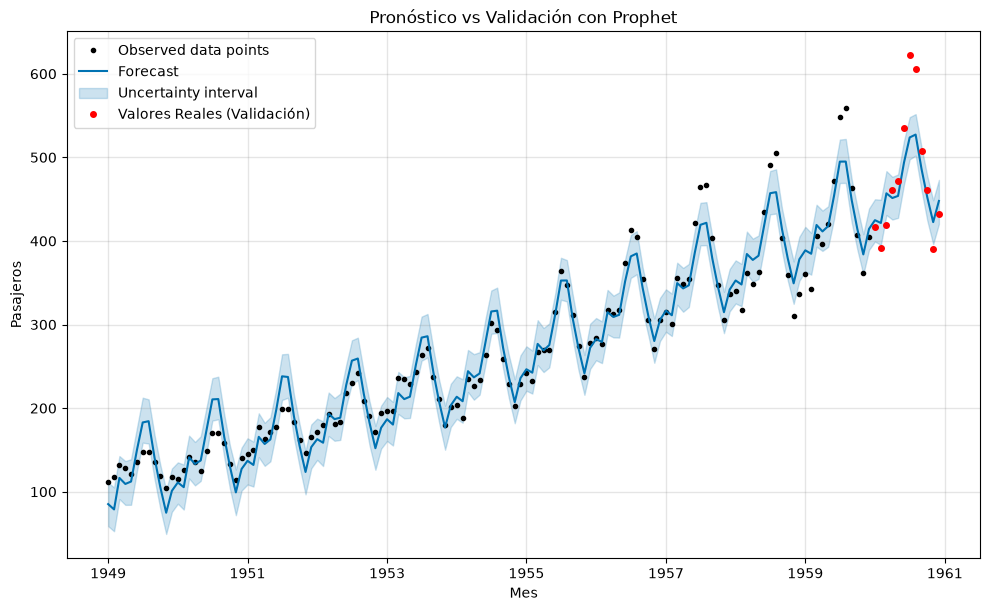

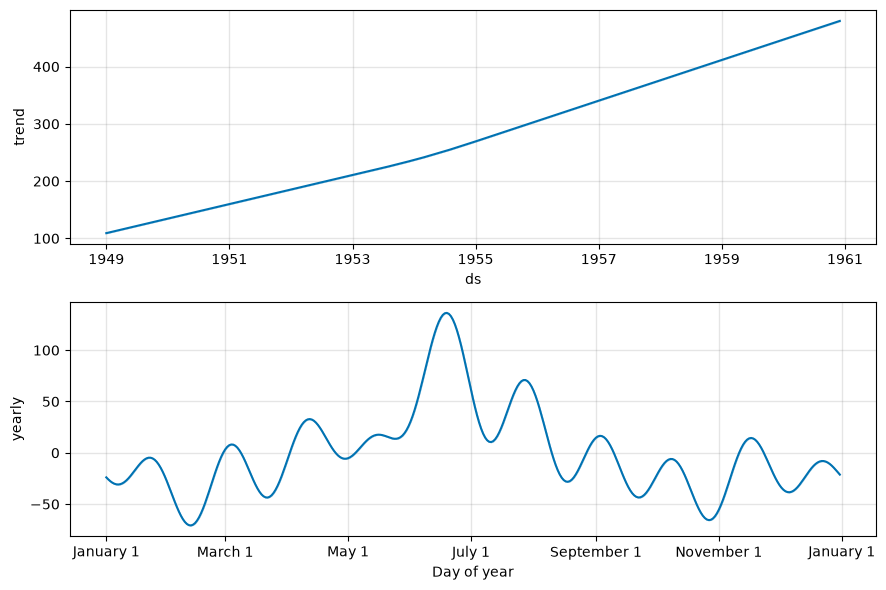

In [ ]:
# PROPHET último año como validación
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# Cargar datos de ejemplo
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])
data = data.asfreq('MS')
series = data['Passengers']

data = data.reset_index()
data.columns = ['ds', 'y']

# MODIFICACIÓN: Dividir en Entrenamiento y Validación (Últimos 12 meses)
train_data = data.iloc[:-12]
val_data = data.iloc[-12:]

# Visualizar datos
plt.figure(figsize=(10, 6))
plt.plot(train_data['ds'], train_data['y'], label='Entrenamiento', color='blue')
plt.plot(val_data['ds'], val_data['y'], label='Validación (Último Año)', color='orange')
plt.title('División de Datos: Entrenamiento vs Validación')
plt.xlabel('Mes')
plt.ylabel('Cantidad de pasajeros')
plt.legend()
plt.show()

# Construir y entrenar el modelo SOLO con los datos de entrenamiento
model = Prophet()
model.fit(train_data) 

# Realizar pronósticos para el periodo de validación
# Nota: periods=12 con freq='MS' genera los meses del año de validación
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# MODIFICACIÓN: Graficar Pronóstico vs Valores Reales de Validación
fig = model.plot(forecast)
plt.plot(val_data['ds'], val_data['y'], 'ro', label='Valores Reales (Validación)', markersize=4)
plt.title('Pronóstico vs Validación con Prophet')
plt.xlabel('Mes')
plt.ylabel('Pasajeros')
plt.legend()
plt.show()

# Visualizar componentes del modelo
fig2 = model.plot_components(forecast)
plt.show()


Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


113/113 - 1s - 13ms/step - loss: 0.0336
Epoch 2/20
113/113 - 0s - 796us/step - loss: 0.0109
Epoch 3/20
113/113 - 0s - 739us/step - loss: 0.0043
Epoch 4/20
113/113 - 0s - 752us/step - loss: 0.0033
Epoch 5/20
113/113 - 0s - 774us/step - loss: 0.0031
Epoch 6/20
113/113 - 0s - 772us/step - loss: 0.0031
Epoch 7/20
113/113 - 0s - 765us/step - loss: 0.0031
Epoch 8/20
113/113 - 0s - 721us/step - loss: 0.0035
Epoch 9/20
113/113 - 0s - 764us/step - loss: 0.0031
Epoch 10/20
113/113 - 0s - 751us/step - loss: 0.0030
Epoch 11/20
113/113 - 0s - 749us/step - loss: 0.0030
Epoch 12/20
113/113 - 0s - 758us/step - loss: 0.0029
Epoch 13/20
113/113 - 0s - 754us/step - loss: 0.0030
Epoch 14/20
113/113 - 0s - 720us/step - loss: 0.0032
Epoch 15/20
113/113 - 0s - 762us/step - loss: 0.0031
Epoch 16/20
113/113 - 0s - 772us/step - loss: 0.0030
Epoch 17/20
113/113 - 0s - 746us/step - loss: 0.0032
Epoch 18/20
113/113 - 0s - 755us/step - loss: 0.0030
Epoch 19/20
113/113 - 0s - 762us/step - loss: 0.0032
Epoch 20/20
11

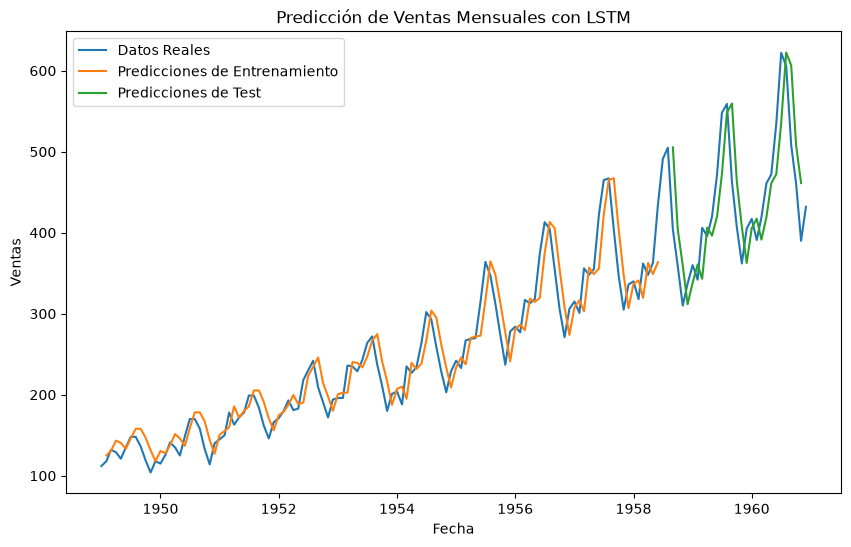

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Cargar datos 
data2 = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])

# Preprocesamiento de datos
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data2.values)

train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back - 1):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 1
X_train, y_train = create_dataset(train, look_back)
X_test, y_test = create_dataset(test, look_back)

# Reshape data to [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Construir el modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(1, look_back)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=20, batch_size=1, verbose=2)

# Realizar predicciones
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invertir la normalización de los datos
train_predict = scaler.inverse_transform(train_predict)
y_train = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform([y_test])

# Visualizar resultados
plt.figure(figsize=(10, 6))
plt.plot(data2.index, data2.values, label='Datos Reales')
plt.plot(data2.index[look_back:len(train_predict) + look_back], train_predict, label='Predicciones de Entrenamiento')
plt.plot(data2.index[len(train_predict) + (look_back * 2) + 1:len(data2) - 1], test_predict, label='Predicciones de Test')
plt.title('Predicción de Ventas Mensuales con LSTM')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()


Epoch 1/50


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0171
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0099
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0092
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0091
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0087
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0080
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0052
Epoch 9/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0081
Epoch 10/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0036
Epoch 11/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034
Epoch 12/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028
Epoch 13/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030
Epoch 14/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032
Epoch 15/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0026 

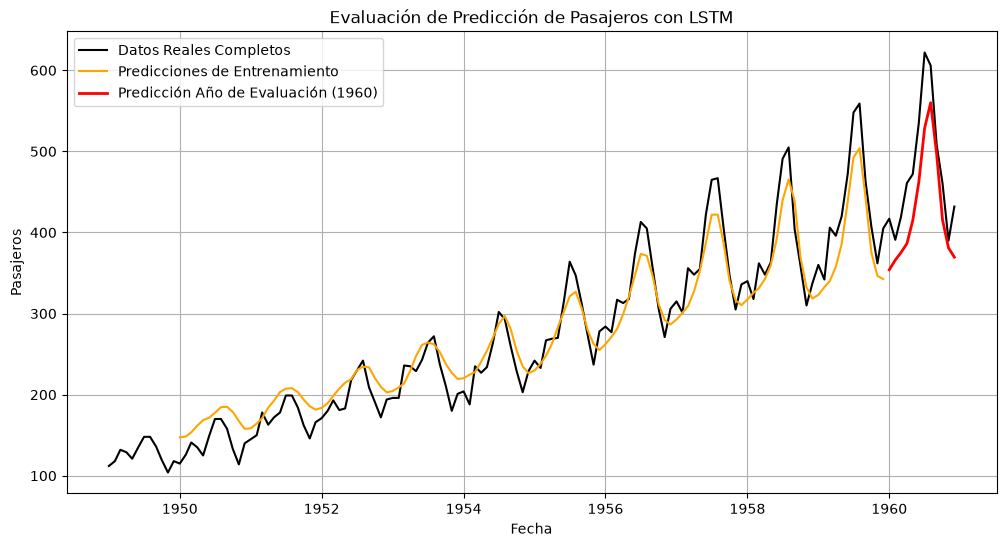

In [ ]:
## CONSTRUIR EL MODELO CON TODOS MENOS EL ÚLTMO AÑO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Cargar datos
df = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])
df = df.asfreq('MS')

# Escalar los datos
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

# Separar los últimos 12 meses (el último año: 1960) para pruebas
train_data = scaled_data[:-12]
test_data = scaled_data[-12:]

# Crear las secuencias temporales (Look-back)
def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 12  # Aumentamos a 12 para que el LSTM capte la estacionalidad anual
X_train, y_train = create_dataset(train_data, look_back)

# Para test, usamos los últimos 'look_back' valores del entrenamiento para predecir el primer mes de test
inputs = scaled_data[len(scaled_data) - len(test_data) - look_back:]
X_test, y_test = create_dataset(inputs, look_back)

# Redimensionar para la red LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Entrenar el modelo LSTM
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train, y_train, epochs=50, batch_size=1, verbose=1)

# Predicciones y revertir el escalado
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluar numéricamente la precisión en el último año
rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
mae = mean_absolute_error(y_test_inv, test_predict)
print(f"--- EVALUACIÓN DEL MODELO (AÑO 1960) ---")
print(f"Error Cuadrático Medio (RMSE): {rmse:.2f} pasajeros")
print(f"Error Absoluto Medio (MAE): {mae:.2f} pasajeros")

# Graficar alineando las fechas correspondientes
plt.figure(figsize=(12, 6))
plt.plot(df.index, df.values, label='Datos Reales Completos', color='black')

# Fechas de entrenamiento 
train_dates = df.index[look_back:len(train_predict) + look_back]
plt.plot(train_dates, train_predict, label='Predicciones de Entrenamiento', color='orange')

# Fechas del último año (Test)
test_dates = df.index[-12:]
plt.plot(test_dates, test_predict, label='Predicción Año de Evaluación (1960)', color='red', linewidth=2)

plt.title('Evaluación de Predicción de Pasajeros con LSTM')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(True)
plt.show()


In [35]:
# CON TODOS LOS DATOS
# Usar la totalidad del arreglo escalado para el entrenamiento
X_all, y_all = create_dataset(scaled_data, look_back=12)
X_all = np.reshape(X_all, (X_all.shape[0], X_all.shape[1], 1))

# Ajustar el modelo con el dataset completo
model.fit(X_all, y_all, epochs=50, batch_size=1)


Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0021
Epoch 9/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 10/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018
Epoch 11/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015
Epoch 12/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 13/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 14/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 15/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

--- PRONÓSTICO GENERADO PARA EL AÑO 1961 ---
            Pronóstico_LSTM
1961-01-01       378.564545
1961-02-01       381.924469
1961-03-01       386.233978
1961-04-01       389.007904
1961-05-01       393.864410
1961-06-01       410.937775
1961-07-01       443.850891
1961-08-01       465.262634
1961-09-01       456.185822
1961-10-01       437.637726
1961-11-01       409.899078
1961-12-01       389.847809


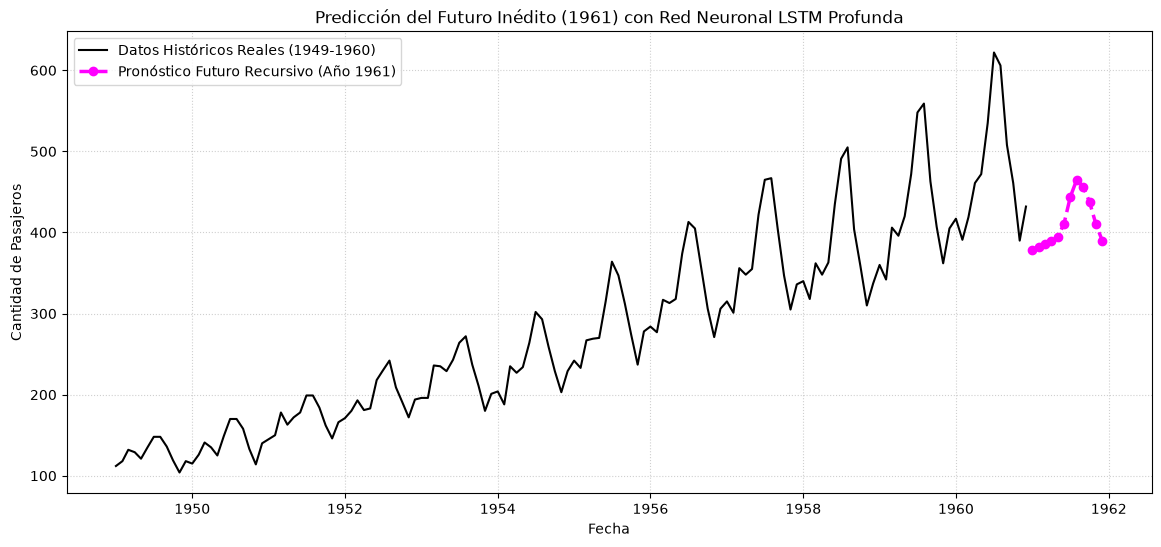

In [ ]:
## PREDICCIÓN 1961
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# CONFIGURACIÓN DEL PRONÓSTICO 
pasos_futuros = 12  # Pronosticar los 12 meses de 1961
look_back = 12

# Tomar los últimos 'look_back' meses de la serie completa escalada (Todo 1960)
# Esta será la ventana inicial para predecir Enero de 1961
ventana_actual = list(scaled_data[-look_back:].flatten())

predicciones_futuras_escaladas = []

for i in range(pasos_futuros):
    # Convertir la lista a la forma requerida por la red LSTM: [samples, time steps, features]
    input_tensor = np.array(ventana_actual[-look_back:])
    input_tensor = np.reshape(input_tensor, (1, look_back, 1))
    
    # Realizar la predicción del siguiente mes
    prediccion_mes_siguiente = model.predict(input_tensor, verbose=0)
    
    # Guardar el resultado obtenido (en escala 0-1)
    predicciones_futuras_escaladas.append(prediccion_mes_siguiente[0, 0])
    
    # RECURSIÓN: Añadir la predicción a la ventana para usarla en la siguiente iteración
    ventana_actual.append(prediccion_mes_siguiente[0, 0])

# REVERTIR EL ESCALADO MATEMÁTICO
predicciones_futuras_escaladas = np.array(predicciones_futuras_escaladas).reshape(-1, 1)
pronostico_1961 = scaler.inverse_transform(predicciones_futuras_escaladas)

# Generar los meses de Enero de 1961 a Diciembre de 1961
fechas_futuras = pd.date_range(start=df.index[-1] + pd.offsets.MonthBegin(1), 
                               periods=pasos_futuros, 
                               freq='MS')

# Consolidar el pronóstico en un DataFrame 
df_pronostico = pd.DataFrame(data=pronostico_1961, index=fechas_futuras, columns=['Pronóstico_LSTM'])

print("--- PRONÓSTICO GENERADO PARA EL AÑO 1961 ---")
print(df_pronostico)

# VISUALIZACIÓN GRÁFICA DEL FUTURO REAL
plt.figure(figsize=(14, 6))

# Graficar la historia real completa (1949 - 1960)
plt.plot(df.index, df.values, label='Datos Históricos Reales (1949-1960)', color='black', linewidth=1.5)

# Graficar el año 1961 proyectado
plt.plot(df_pronostico.index, df_pronostico['Pronóstico_LSTM'], 
         label='Pronóstico Futuro Recursivo (Año 1961)', 
         color='magenta', linestyle='--', linewidth=2.5, marker='o')

plt.title('Predicción del Futuro Inédito (1961) con Red Neuronal LSTM Profunda')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


02:40:29 - cmdstanpy - INFO - Chain [1] start processing
02:40:29 - cmdstanpy - INFO - Chain [1] done processing


--- EVALUACIÓN PROPHET (AÑO DE PRUEBA 1960) ---
Error Cuadrático Medio (RMSE): 43.07 pasajeros
Error Absoluto Medio (MAE): 33.44 pasajeros


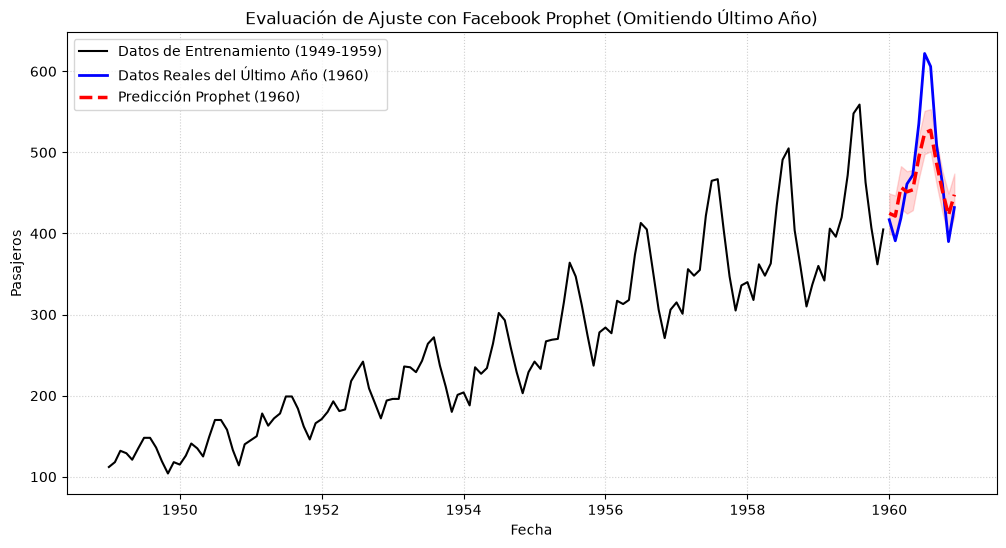

In [ ]:
#Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Cargar datos de ejemplo de base 
data = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col=['Month'])
data = data.asfreq('MS')

# Preparación de datos 
data = data.reset_index()
data.columns = ['ds', 'y']

# Entrenar con los años de 1949 a 1959
# Quitamos las últimas 12 filas correspondientes a los 12 meses de 1960
train_data = data[:-12]
test_data = data[-12:]

# Entrenar el modelo Prophet básico 
model = Prophet()
model.fit(train_data)

# Realizar pronósticos para el periodo de evaluación
# Generamos una estructura para los 12 meses de 1960
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

# Filtrar las predicciones para emparejarlas con el año de prueba (1960)
forecast_test = forecast.set_index('ds').loc[test_data['ds']]

# Evaluar numéricamente qué tan bien se ajusta el modelo
y_real = test_data['y'].values
y_pred = forecast_test['yhat'].values

rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae = mean_absolute_error(y_real, y_pred)

print(f"--- EVALUACIÓN PROPHET (AÑO DE PRUEBA 1960) ---")
print(f"Error Cuadrático Medio (RMSE): {rmse:.2f} pasajeros")
print(f"Error Absoluto Medio (MAE): {mae:.2f} pasajeros")

# Visualizar pronósticos y ajuste real en un gráfico integrado 
plt.figure(figsize=(12, 6))

# Datos de entrenamiento históricos
plt.plot(train_data['ds'], train_data['y'], label='Datos de Entrenamiento (1949-1959)', color='black')

# Datos reales retenidos para evaluar el ajuste
plt.plot(test_data['ds'], test_data['y'], label='Datos Reales del Último Año (1960)', color='blue', linewidth=2)

# Predicción generada por Prophet
plt.plot(forecast_test.index, forecast_test['yhat'], label='Predicción Prophet (1960)', color='red', linestyle='--', linewidth=2.5)

# Sombreado de los intervalos de confianza o incertidumbre (yhat_lower y yhat_upper)
plt.fill_between(forecast_test.index, forecast_test['yhat_lower'], forecast_test['yhat_upper'], color='red', alpha=0.15)

plt.title('Evaluación de Ajuste con Facebook Prophet (Omitiendo Último Año)')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
